# Notebook 01 — Exploratory Data Analysis

## Environment Setup and Library Imports

This section initializes the working environment by importing all required libraries and configuring paths for the project. It also loads key constants from the configuration file and sets up plotting aesthetics for consistent visualisation across the notebook.

The configuration file centralises important parameters such as dataset paths, plotting directories, and text-processing settings, ensuring reproducibility and maintainability.

Additionally, plotting styles are standardised and necessary directories for storing EDA outputs are created.

In [1]:
# System path setup 
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Text processing and analysis
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

import re

# Project configuration 
from config import (
    RAW_CSV, PLOTS_DIR, MAX_LENGTH,
    WORDCLOUD_MAX, TOP_N_NGRAMS, 
    NEGATION_CUES, INTENSIFIERS,
)

# Global plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Class-wise colour palette
PALETTE = {
    'suicide': '#E63946',
    'non-suicide': '#457B9D'
}

# Create directory for EDA outputs
os.makedirs(PLOTS_DIR / 'eda', exist_ok=True)

## Data Loading and Initial Cleaning

Load the dataset from the configured path and perform basic cleaning. This includes standardising column names, renaming the target variable, handling missing values, and resetting the index for consistency.

In [2]:
# Load dataset
df = pd.read_csv(RAW_CSV, index_col=0)

# Standardise column names
df.columns = df.columns.str.strip()

# Rename target column for consistency
df.rename(columns={'class': 'label'}, inplace=True)

# Remove rows with missing text or labels
df.dropna(subset=['text', 'label'], inplace=True)

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

# Basic dataset inspection
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

df.head()

Dataset shape: (232074, 2)
Columns: ['text', 'label']


,text,label
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


## Class Distribution Analysis

Compute the distribution of target labels in terms of absolute counts and percentage share to understand class balance in the dataset.

In [3]:
# Compute class distribution (counts and percentages)
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

# Display results
print(class_counts.to_string())
print()
print(class_pct.round(2).to_string())

label
suicide        116037
non-suicide    116037

label
suicide        50.0
non-suicide    50.0


## Class Distribution Visualisation

Visualise the distribution of target labels using both absolute counts and percentage share. This helps assess class balance and identify potential imbalance issues.

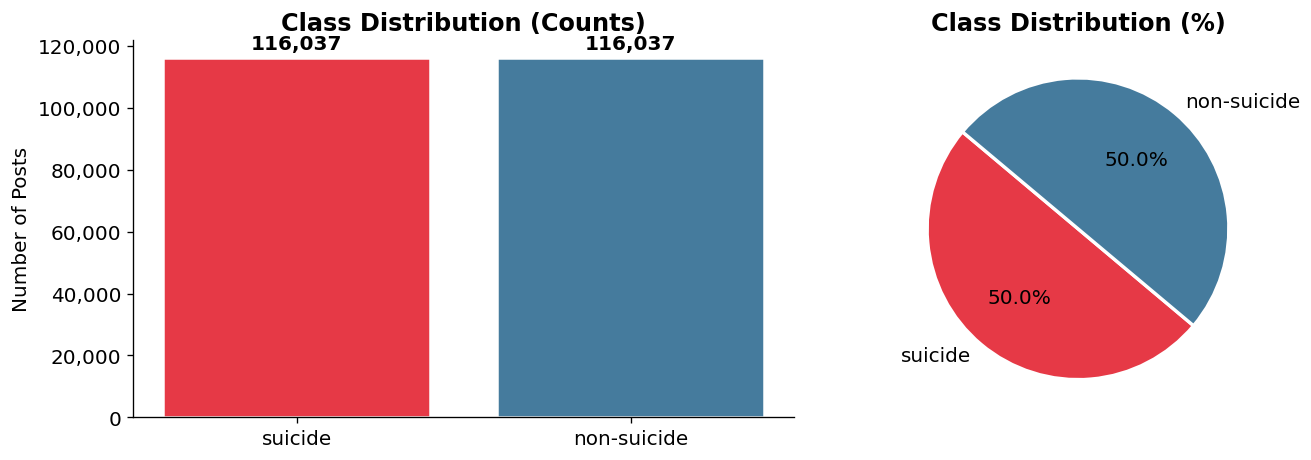

Observation: Dataset is roughly balanced — minimal class weighting needed.


In [4]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart for class counts
bars = axes[0].bar(
    class_counts.index,
    class_counts.values,
    color=[PALETTE[c] for c in class_counts.index],
    edgecolor='white',
    linewidth=1.5
)

# Annotate bar values
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1500,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

axes[0].set_title('Class Distribution (Counts)', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Pie chart for percentage distribution
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=[PALETTE[c] for c in class_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Class Distribution (%)', fontweight='bold')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'class_distribution.png', bbox_inches='tight')
plt.show()

print('Observation: Dataset is roughly balanced — minimal class weighting needed.')

## Text Length Feature Engineering

Derive basic textual features including character length, word count, and sentence count. These features help analyse structural differences between classes.

In [5]:
# Compute text-based features
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['sent_count'] = df['text'].str.count(r'[.!?]') + 1

# Generate descriptive statistics grouped by label
summary = df.groupby('label')[['char_len', 'word_count', 'sent_count']].describe().round(1)
print(summary)

             char_len                                                      \
                count    mean     std  min    25%    50%     75%      max   
label                                                                       
non-suicide  116037.0   329.2   806.4  8.0   99.0  165.0   320.0  40106.0   
suicide      116037.0  1050.1  1328.2  3.0  310.0  653.0  1294.0  40297.0   

            word_count         ...                sent_count                   \
                 count   mean  ...    75%     max      count  mean   std  min   
label                          ...                                              
non-suicide   116037.0   61.2  ...   60.0  8220.0   116037.0   5.5  60.8  1.0   
suicide       116037.0  202.7  ...  251.0  9684.0   116037.0  15.8  21.1  1.0   

                                       
             25%   50%   75%      max  
label                                  
non-suicide  1.0   3.0   5.0  10673.0  
suicide      5.0  10.0  19.0   1938.0  

[2 rows

## Text Length Distribution Analysis

Visualise the distribution of text-based features across classes using kernel density estimation. Extreme values are clipped at the 99th percentile to reduce the impact of outliers.

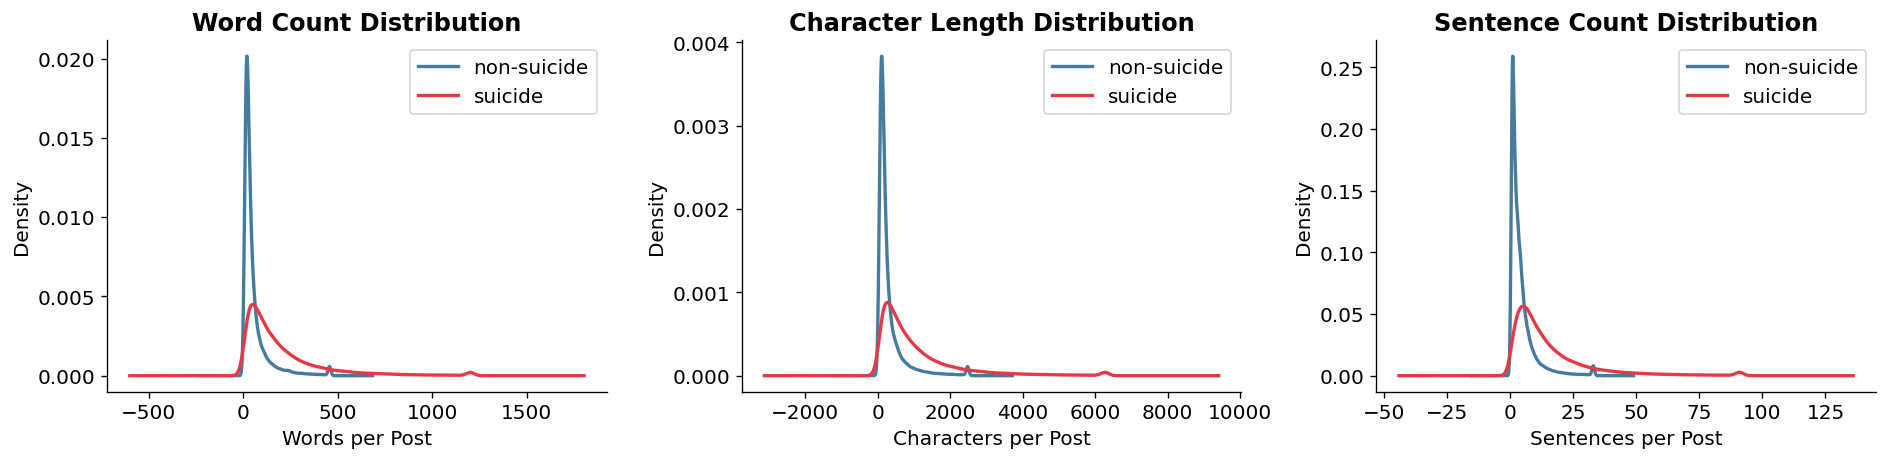

In [6]:
# Create subplots for feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot KDE distributions for each feature
for ax, col, title, xlabel in zip(
    axes,
    ['word_count', 'char_len', 'sent_count'],
    ['Word Count Distribution', 'Character Length Distribution', 'Sentence Count Distribution'],
    ['Words per Post', 'Characters per Post', 'Sentences per Post']
):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.kde(
            ax=ax,
            label=label,
            color=PALETTE[label],
            linewidth=2
        )
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'text_length_distribution.png', bbox_inches='tight')
plt.show()

## Word Count Distribution by Class

Use box plots to compare the distribution of word counts across classes. This provides insight into median differences, spread, and presence of outliers.

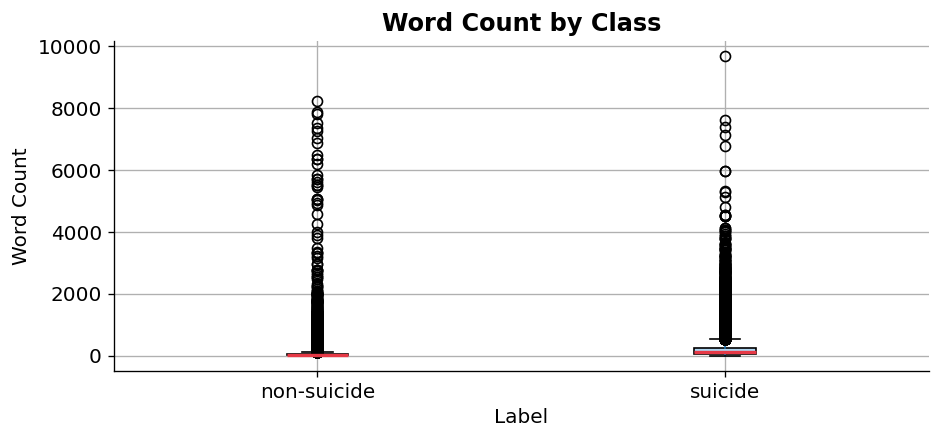

In [7]:
# Box plot for word count grouped by label
fig, ax = plt.subplots(figsize=(8, 4))

df.boxplot(
    column='word_count',
    by='label',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1'),
    medianprops=dict(color='#E63946', linewidth=2)
)

ax.set_title('Word Count by Class', fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Word Count')

# Remove default pandas title
plt.suptitle('')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'wordcount_boxplot.png', bbox_inches='tight')
plt.show()

## Sequence Length and Truncation Analysis

Estimate the proportion of posts exceeding the maximum sequence length using word count as a proxy for token count. This helps evaluate potential information loss due to truncation.

Approximate % of posts that will be truncated at MAX_LENGTH=256: 13.7%


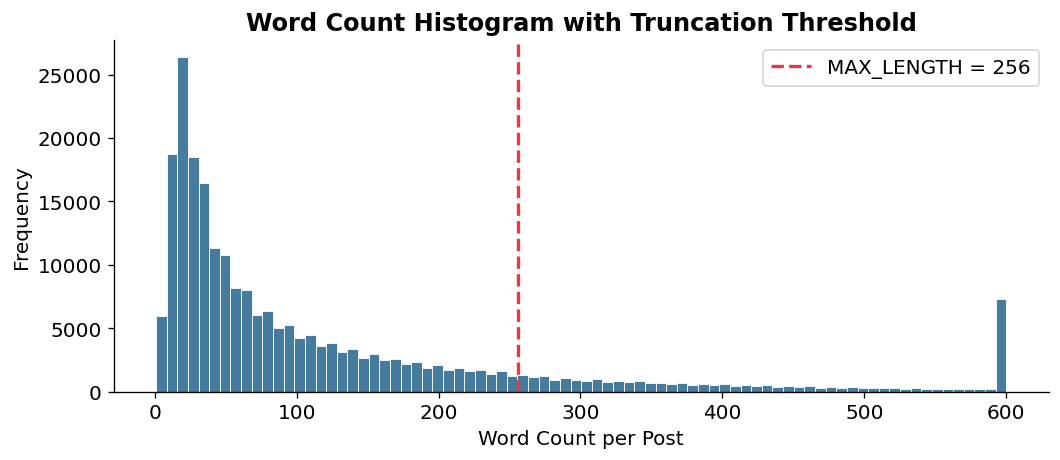

In [8]:
# Estimate truncation percentage using word count as proxy for tokens
pct_truncated = (df['word_count'] > MAX_LENGTH).mean() * 100

print(f'Approximate % of posts that will be truncated at MAX_LENGTH={MAX_LENGTH}: {pct_truncated:.1f}%')

# Plot histogram of word counts with truncation threshold
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    df['word_count'].clip(upper=600),
    bins=80,
    color='#457B9D',
    edgecolor='white',
    linewidth=0.5
)

# Mark truncation threshold
ax.axvline(
    MAX_LENGTH,
    color='#E63946',
    linewidth=2,
    linestyle='--',
    label=f'MAX_LENGTH = {MAX_LENGTH}'
)

ax.set_xlabel('Word Count per Post')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Histogram with Truncation Threshold', fontweight='bold')
ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'truncation_threshold.png', bbox_inches='tight')
plt.show()

## Word Cloud Analysis

Generate word clouds for each class to identify frequently occurring terms. Minimal preprocessing is applied to remove URLs and punctuation while preserving core textual patterns.

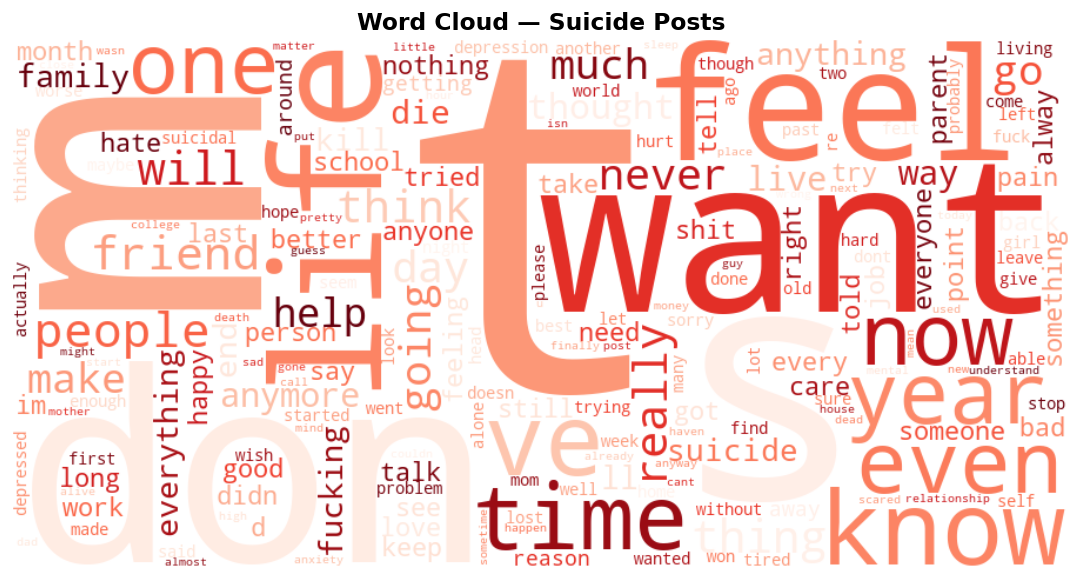

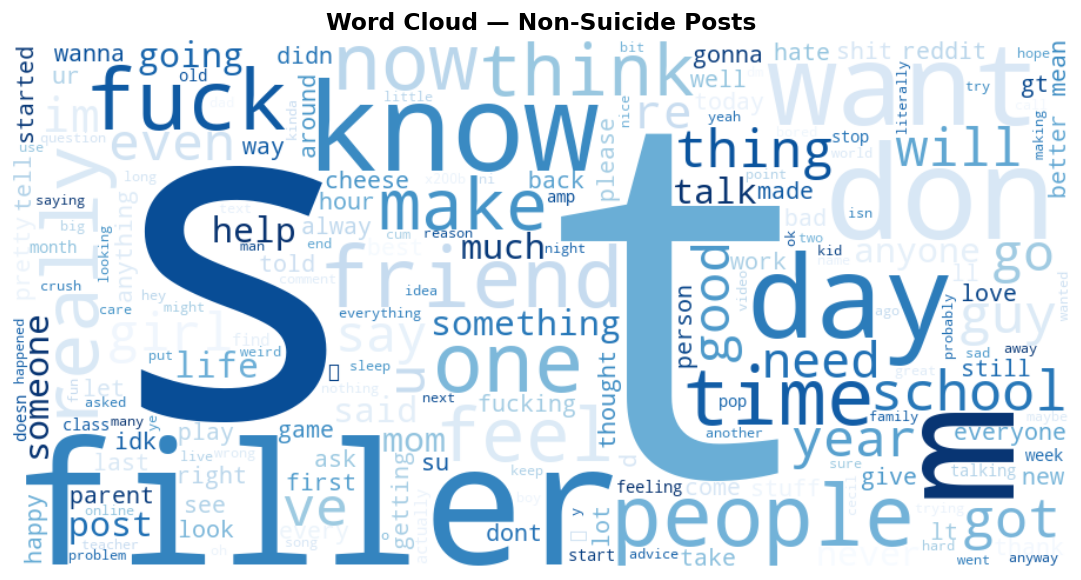

In [9]:
# Minimal text cleaning for word cloud generation
def simple_clean(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.lower()

# Generate word clouds for each class
for label in ['suicide', 'non-suicide']:
    corpus = ' '.join(df[df['label'] == label]['text'].apply(simple_clean))

    wc = WordCloud(
        width=900,
        height=450,
        background_color='white',
        colormap='Reds' if label == 'suicide' else 'Blues',
        max_words=WORDCLOUD_MAX,
        collocations=False
    ).generate(corpus)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.title()} Posts', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig(
        PLOTS_DIR / 'eda' / f'wordcloud_{label.replace("-", "_")}.png',
        bbox_inches='tight'
    )
    plt.show()

## N-gram Frequency Analysis

Extract and visualise the most frequent unigrams and bigrams for each class. This helps identify common linguistic patterns and distinguishing phrases across categories.

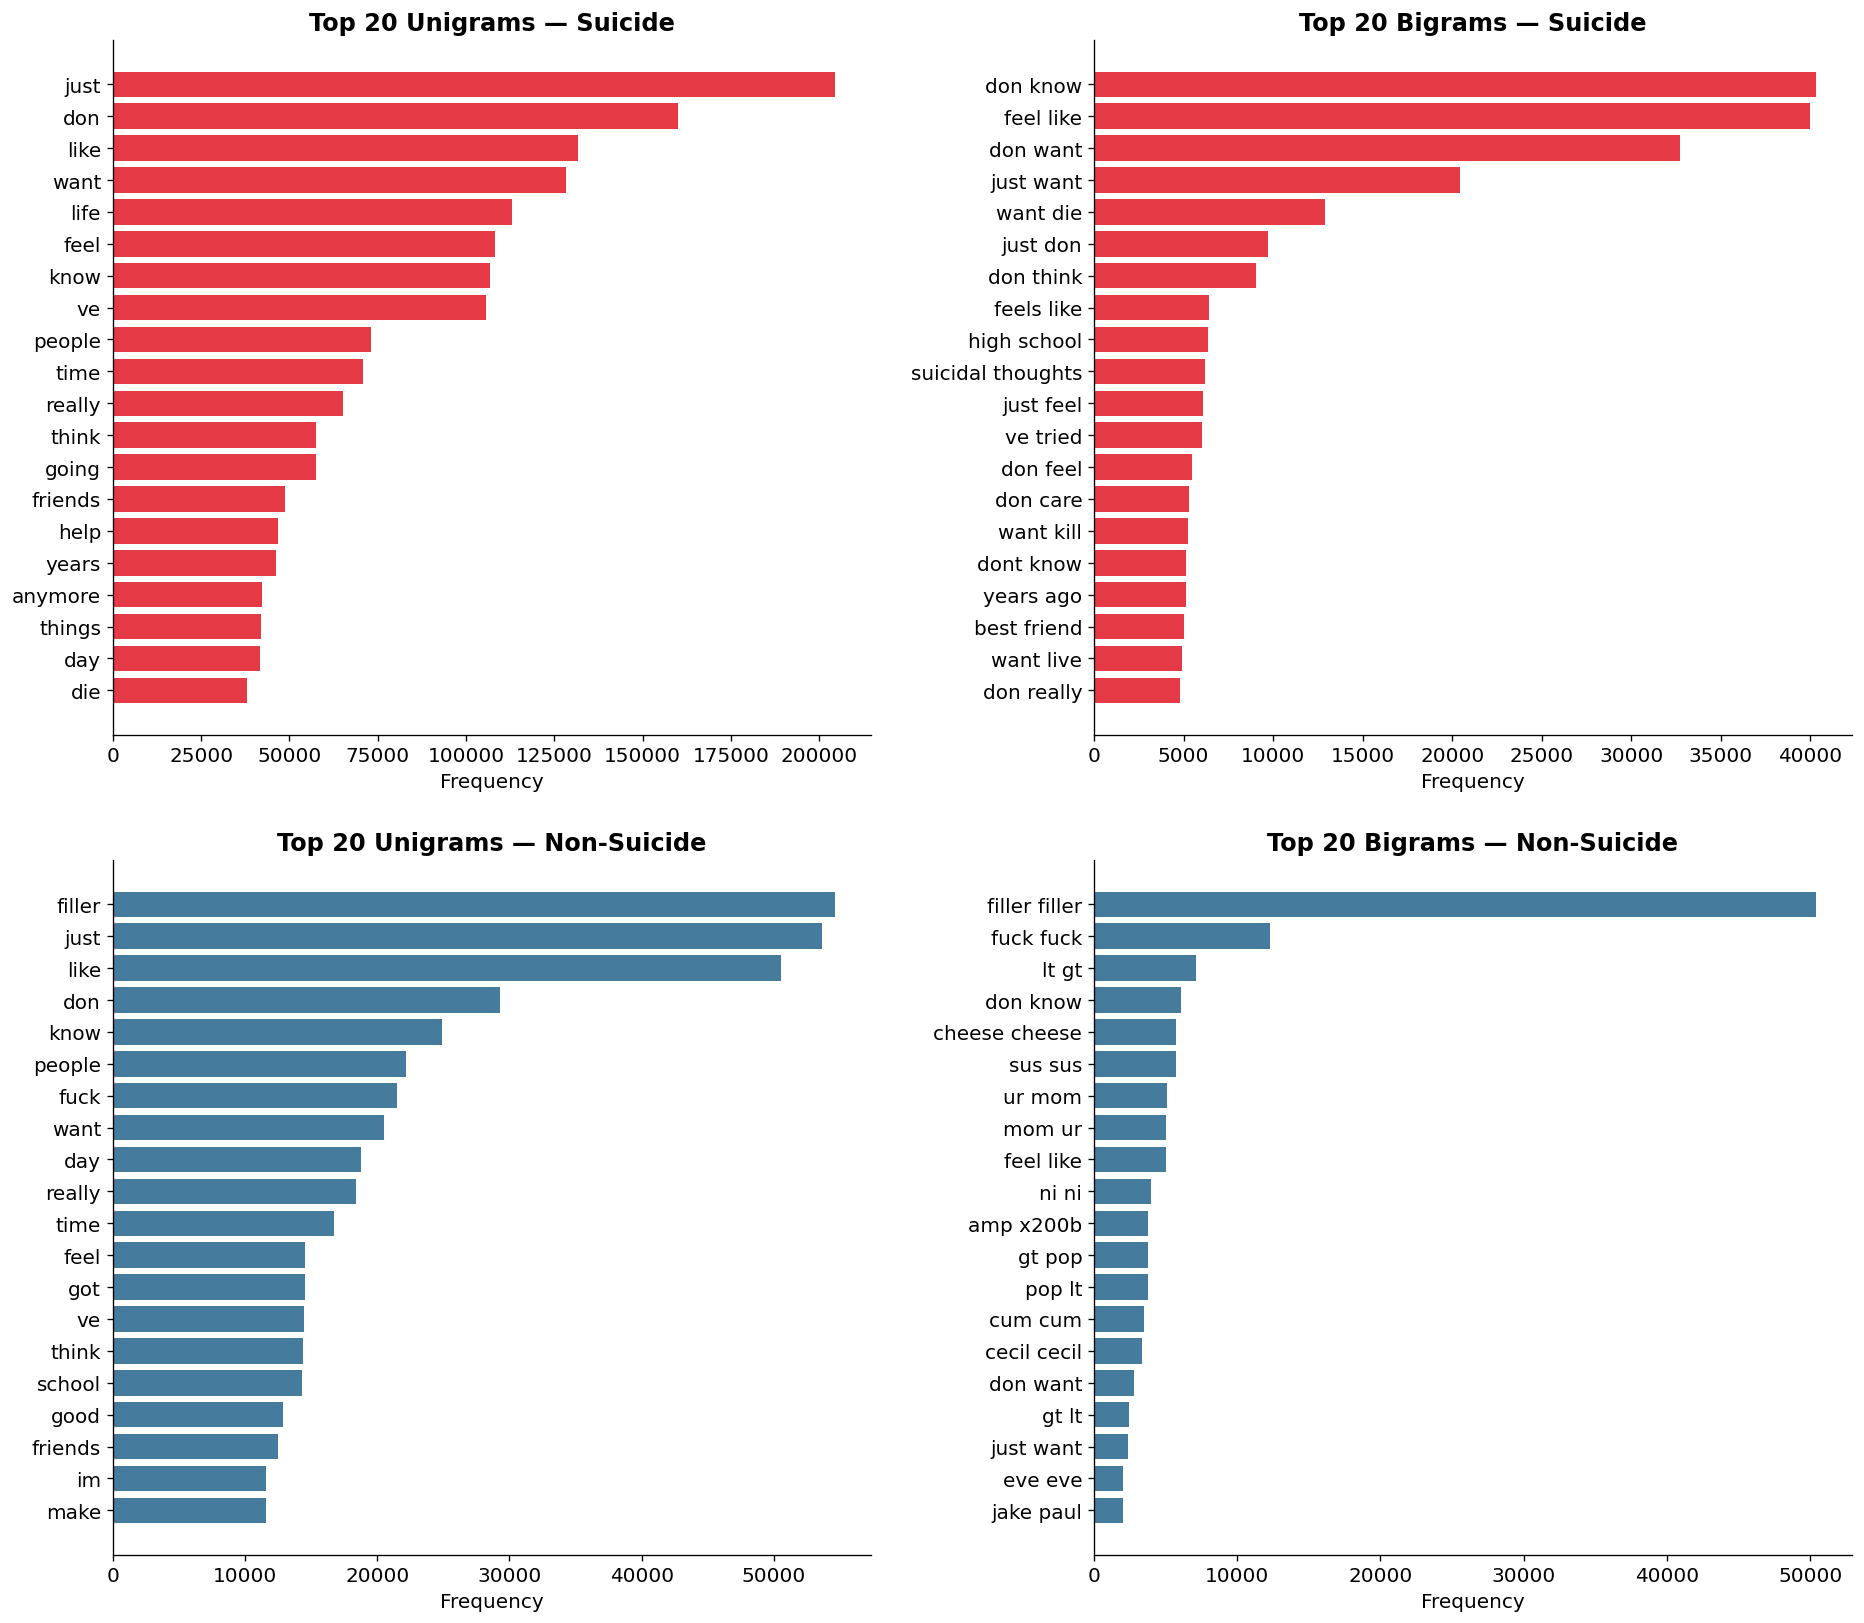

In [10]:
# Function to plot top n-grams
def plot_top_ngrams(corpus, n=1, top_k=20, ax=None, title='', color='steelblue'):
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=50_000
    ).fit(corpus)

    bag = vec.transform(corpus)
    counts = bag.sum(axis=0).A1

    # Select top-k n-grams
    top_idx = counts.argsort()[-top_k:][::-1]
    terms = [vec.get_feature_names_out()[i] for i in top_idx]
    vals = [counts[i] for i in top_idx]

    # Plot horizontal bar chart
    ax.barh(terms[::-1], vals[::-1], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')


# Create subplots for unigrams and bigrams across classes
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for row, label in enumerate(['suicide', 'non-suicide']):
    corpus = df[df['label'] == label]['text'].apply(simple_clean)
    color = PALETTE[label]

    for col, n, ng_label in [(0, 1, 'Unigrams'), (1, 2, 'Bigrams')]:
        plot_top_ngrams(
            corpus,
            n=n,
            top_k=TOP_N_NGRAMS,
            ax=axes[row][col],
            title=f'Top {TOP_N_NGRAMS} {ng_label} — {label.title()}',
            color=color
        )

# Adjust layout and save figure
plt.tight_layout(pad=2.0)
plt.savefig(PLOTS_DIR / 'eda' / 'top_ngrams.png', bbox_inches='tight')
plt.show()

## Linguistic Signal Analysis

Compute negation and intensifier usage within each post and normalise by word count. These features capture linguistic cues that may differ across classes.

In [11]:
# Count occurrences of signal words in text
def count_signal_words(text, signal_list):
    tokens = str(text).lower().split()
    return sum(t in signal_list for t in tokens)

# Compute signal counts
df['negation_count'] = df['text'].apply(lambda x: count_signal_words(x, NEGATION_CUES))
df['intensifier_count'] = df['text'].apply(lambda x: count_signal_words(x, INTENSIFIERS))

# Normalise by word count to obtain ratios
df['neg_ratio'] = df['negation_count'] / df['word_count'].clip(lower=1)
df['intens_ratio'] = df['intensifier_count'] / df['word_count'].clip(lower=1)

# Aggregate mean ratios by class
signal_summary = df.groupby('label')[['neg_ratio', 'intens_ratio']].mean().round(4)

print('Mean signal ratios by class:')
print(signal_summary)

Mean signal ratios by class:
             neg_ratio  intens_ratio
label                               
non-suicide     0.0133        0.0129
suicide         0.0258        0.0142


## Linguistic Signal Distribution

Visualise the distribution of negation and intensifier ratios across classes. This highlights differences in linguistic patterns between categories.

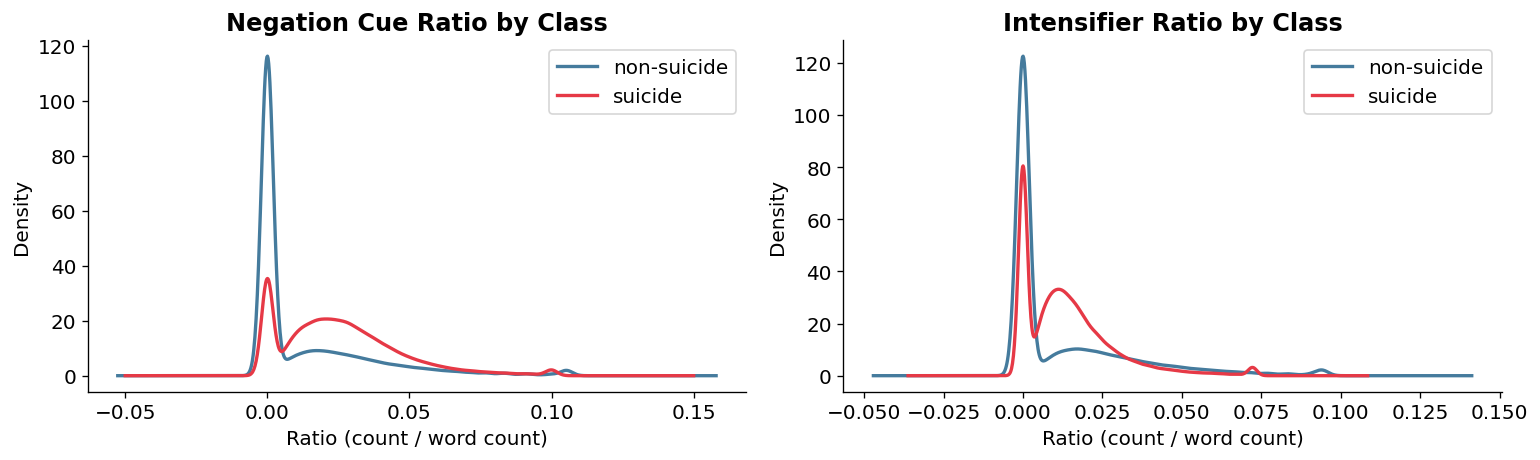

In [12]:
# Create subplots for linguistic signal distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot KDE distributions for each signal feature
for ax, col, title in zip(
    axes,
    ['neg_ratio', 'intens_ratio'],
    ['Negation Cue Ratio by Class', 'Intensifier Ratio by Class']
):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.kde(
            ax=ax,
            label=label,
            color=PALETTE[label],
            linewidth=2
        )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ratio (count / word count)')
    ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'linguistic_signal_distributions.png', bbox_inches='tight')
plt.show()

## Feature Correlation Analysis

Compute and visualise correlations between engineered features and the target variable. This helps identify relationships and potential feature importance for modelling.

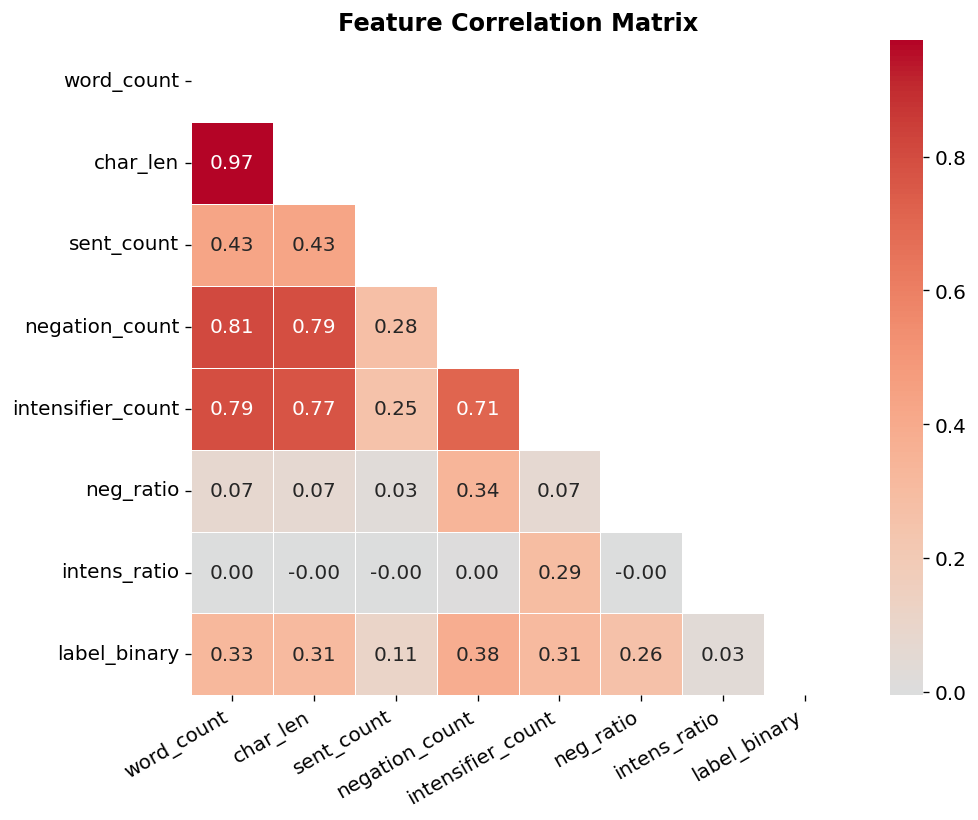

In [13]:
# Map labels to binary values for correlation analysis
df['label_binary'] = df['label'].map({'suicide': 1, 'non-suicide': 0})

# Select numerical features
num_cols = [
    'word_count', 'char_len', 'sent_count',
    'negation_count', 'intensifier_count',
    'neg_ratio', 'intens_ratio', 'label_binary'
]

# Compute correlation matrix
corr = df[num_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5,
    square=True
)

# Rotate x-axis labels to 30 degrees for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Set Heatmap Title
ax.set_title('Feature Correlation Matrix', fontweight='bold')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()